<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/R_F_IOL_STUDY_11626.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
sheets = pd.ExcelFile('/content/drive/MyDrive/Keerthi krishna thesis clean data preprocesed.xlsx')
sheets.sheet_names

['rigid IOL',
 'R preop',
 'R pod1',
 'R pod6wks',
 'R pod3mths',
 'foldable IOL',
 'F preop',
 'F pod1',
 'F pod6wks',
 'F pod3mthh',
 'R and F age analysis',
 'Cataract grading ',
 'Laterality ',
 'Gender']

In [3]:
rigid_preop = sheets.parse('R preop')
rigid_pod1 = sheets.parse('R pod1')
rigid_pod6wks = sheets.parse('R pod6wks')
rigid_pod3mths = sheets.parse('R pod3mths')

In [4]:
rigid_pod1.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
       'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
       'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
       'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
       'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
       'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
      dtype='object')

In [5]:
fold_preop = sheets.parse('F preop')
fold_pod1 = sheets.parse('F pod1')
fold_pod6wks = sheets.parse('F pod6wks')
fold_pod3mths = sheets.parse('F pod3mthh')


### Baseline characteristics

R and F age analysis

Gender

Laterality

Cataract grading

Creat Table 1: Baseline Demographic and Clinical Characteristics

In [6]:
rigid_preop.columns, fold_preop.columns

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'Preop IOP-R', 'Preop ACD-R ',
        'Preop LV-R', 'Preop CCT-R ', 'Preop ACA-R  ', 'Preop ATA-R ',
        'Preop AOD N 500-R ', 'preop AOD N 750-R ', 'Preop TISA N 500-R ',
        'Preop TISA N 750-R ', 'Preop SSA-N R ', 'Preop AOD T 500-R  ',
        'Preop AOD T 750-R ', 'Preop TISAT  500-R  ', 'Preop TISA T 750-R ',
        'Preop SSA-T-R'],
       dtype='object'),
 Index(['Name', 'Age (F)', 'Sex (F) ', 'Cataract grading-F ', 'Laterality (F)',
        'Preop VA (F)', ' preop IOP (F)', 'Preop ACD (F)', 'Preop LV (F)',
        'Preop CCT (F)', 'Preop ACA (F) ', 'Preop ATA (F)',
        'Preop AOD N 500 (F)', 'Preop AOD N 750 (F) ', 'Preop TISA N 500 (F)',
        'Preop TISA N 750 (F)', 'Preop SSA-N (F) ', 'Preop AOD T 500 (F) ',
        'Preop AOD T 750 (F) ', 'Preop TISA T 500 (F) ',
        'Preop TISA T 750 (F) ', 'Preop SSA-T (F) '],
       dtype='object

In [7]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

rigid_age = rigid_preop['Age-R'].dropna()
fold_age = fold_preop['Age (F)'].dropna()

if shapiro(rigid_age).pvalue > 0.05 and shapiro(fold_age).pvalue > 0.05:
    stat, p = ttest_ind(rigid_age, fold_age)
else:
    stat, p = mannwhitneyu(rigid_age, fold_age)

print(f"Age p-value = {p:.4f}")

Age p-value = 0.0741


In [8]:
from scipy.stats import shapiro

# Age data
age_rigid = rigid_preop['Age-R'].dropna()
age_fold = fold_preop['Age (F)'].dropna()

# Shapiro-Wilk test
shapiro_rigid = shapiro(age_rigid)
shapiro_fold = shapiro(age_fold)

print("Rigid IOL Age:")
print(f"W = {shapiro_rigid.statistic:.4f}, p = {shapiro_rigid.pvalue:.4f}")

print("\nFoldable IOL Age:")
print(f"W = {shapiro_fold.statistic:.4f}, p = {shapiro_fold.pvalue:.4f}")

Rigid IOL Age:
W = 0.9429, p = 0.1191

Foldable IOL Age:
W = 0.9690, p = 0.5327


In [9]:
from scipy.stats import ttest_ind, mannwhitneyu

if shapiro_rigid.pvalue > 0.05 and shapiro_fold.pvalue > 0.05:
    stat, p = ttest_ind(age_rigid, age_fold)
    print(f"Independent t-test: p = {p:.4f}")
else:
    stat, p = mannwhitneyu(age_rigid, age_fold)
    print(f"Mann-Whitney U test: p = {p:.4f}")

Independent t-test: p = 0.0741


In [10]:
rigid_gender_counts = rigid_preop['Sex-R'].value_counts().rename('Rigid Count')
fold_gender_counts = fold_preop['Sex (F) '].value_counts().rename('Foldable Count')

gender_df = pd.concat([rigid_gender_counts, fold_gender_counts], axis=1)
gender_df.index.name = 'Gender'
gender_df = gender_df.fillna(0).astype(int)

gender_df['Rigid %'] = (
    gender_df['Rigid Count'] /
    gender_df['Rigid Count'].sum() * 100
).round(1)

gender_df['Foldable %'] = (
    gender_df['Foldable Count'] /
    gender_df['Foldable Count'].sum() * 100
).round(1)

print(gender_df)

        Rigid Count  Foldable Count  Rigid %  Foldable %
Gender                                                  
F                15              17     51.7        58.6
M                14              12     48.3        41.4


In [11]:
from scipy.stats import chi2_contingency

table = gender_df[['Rigid Count','Foldable Count']].values

chi2, p, dof, expected = chi2_contingency(table)

print("Gender p-value =", p)

Gender p-value = 0.7917572434026547


In [12]:
rigid_laterality_counts = rigid_preop['Laterality-R'].value_counts().rename('Rigid Count')
fold_laterality_counts = fold_preop['Laterality (F)'].value_counts().rename('Foldable Count')

laterality_df = pd.concat([rigid_laterality_counts, fold_laterality_counts], axis=1)
laterality_df.index.name = 'Laterality'
laterality_df = laterality_df.fillna(0).astype(int)

table = laterality_df[['Rigid Count','Foldable Count']].values

chi2, p, dof, expected = chi2_contingency(table)

print("Laterality p-value =", p)
print(laterality_df)

Laterality p-value = 2.9571317267959e-07
            Rigid Count  Foldable Count
Laterality                             
LE                   16               0
RE                    5               0
RE                    4              11
LE                    4              18


In [13]:
rigid_cataract_counts = rigid_preop['Cataract grading-R '].value_counts().rename('Rigid Count')
fold_cataract_counts = fold_preop['Cataract grading-F '].value_counts().rename('Foldable Count')

cataract_df = pd.concat([rigid_cataract_counts, fold_cataract_counts], axis=1)
cataract_df.index.name = 'Cataract Grade'
cataract_df = cataract_df.fillna(0).astype(int)

table = cataract_df[['Rigid Count','Foldable Count']].values

chi2, p, dof, expected = chi2_contingency(table)

print("Cataract grade p-value =", p)
print(cataract_df)

Cataract grade p-value = 0.12831352788995495
                Rigid Count  Foldable Count
Cataract Grade                             
NC                        4               5
NS 3                      4               0
NS 4                      4               1
MC                        3               2
 NC                       2               0
NS 1+PSC                  2               1
NMC                       2               1
 NS 3                     2               0
NS 2+PSC                  2               1
 MC                       1               0
PPC                       1               0
NS 2                      1               0
 NS 2                     1               0
NS4                       0               3
NS3                       0               3
NS                        0               2
NS 3                      0               1
NS3+PSC                   0               1
NS2+PSC                   0               1
NS2                       0    

In [14]:
cataract_df.index = (
    cataract_df.index
    .str.upper()
    .str.strip()
    .str.replace('NS3', 'NS 3')
    .str.replace('NS4', 'NS 4')
    .str.replace('NS2', 'NS 2')
    .str.replace('  ', ' ', regex=False)
    .str.replace('LE ', '')
    .str.replace('RE ', '')
)

In [15]:
cataract_df.index = (
    cataract_df.index.astype(str)
    .str.upper()
    .str.strip()
    .str.replace('NS3', 'NS 3', regex=False)
    .str.replace('NS4', 'NS 4', regex=False)
    .str.replace('NS2', 'NS 2', regex=False)
    .str.replace('  ', ' ', regex=False)
    .str.replace('LE ', '', regex=False)
    .str.replace('RE ', '', regex=False)
)

# Merge duplicate categories created by cleaning
cataract_df = cataract_df.groupby(level=0).sum()

cataract_df

,Rigid Count,Foldable Count
Cataract Grade,,
MC,4,2
NC,6,6
NMC,2,2
NS,0,2
NS 1+PSC,2,1
NS 2,2,1
NS 2 + PSC,0,1
NS 2+PSC,2,2
NS 3,6,5


In [16]:
total_rigid = cataract_df['Rigid Count'].sum()
total_fold = cataract_df['Foldable Count'].sum()

table = cataract_df.copy()

table['Rigid n (%)'] = (
    table['Rigid Count'].astype(str)
    + ' ('
    + (100 * table['Rigid Count'] / total_rigid).round(1).astype(str)
    + ')'
)

table['Foldable n (%)'] = (
    table['Foldable Count'].astype(str)
    + ' ('
    + (100 * table['Foldable Count'] / total_fold).round(1).astype(str)
    + ')'
)

table = table[['Rigid n (%)', 'Foldable n (%)']]
print(table)

               Rigid n (%) Foldable n (%)
Cataract Grade                           
MC                4 (13.8)        2 (6.9)
NC                6 (20.7)       6 (20.7)
NMC                2 (6.9)        2 (6.9)
NS                 0 (0.0)        2 (6.9)
NS 1+PSC           2 (6.9)        1 (3.4)
NS 2               2 (6.9)        1 (3.4)
NS 2 + PSC         0 (0.0)        1 (3.4)
NS 2+PSC           2 (6.9)        2 (6.9)
NS 3              6 (20.7)       5 (17.2)
NS 3+PSC           0 (0.0)        1 (3.4)
NS 4              4 (13.8)       4 (13.8)
NS 4+PSC           0 (0.0)        1 (3.4)
PPC                1 (3.4)        0 (0.0)
PSC+CC             0 (0.0)        1 (3.4)


This bar chart displays the percentage distribution of different cataract grades for both Rigid and Foldable IOL types. Each bar represents a cataract grade, with different colors distinguishing between Rigid and Foldable IOLs. The height of each bar corresponds to the percentage of patients within that cataract grade for the respective IOL type.

In [17]:
cataract_df.index = (
    cataract_df.index.astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r'\s*\+\s*', '+', regex=True)  # NS 2 + PSC -> NS 2+PSC
    .str.replace(r'\s+', ' ', regex=True)       # remove extra spaces
)

# Combine identical categories
cataract_df = cataract_df.groupby(level=0).sum()

cataract_df

,Rigid Count,Foldable Count
Cataract Grade,,
MC,4,2
NC,6,6
NMC,2,2
NS,0,2
NS 1+PSC,2,1
NS 2,2,1
NS 2+PSC,2,3
NS 3,6,5
NS 3+PSC,0,1


In [18]:
from scipy.stats import chi2_contingency

gender_table = [
    [14, 15],  # Rigid: Male, Female
    [12, 17]   # Foldable: Male, Female
]

chi2, p, dof, expected = chi2_contingency(gender_table)

print(f"Chi-square = {chi2:.3f}")
print(f"p-value = {p:.4f}")

Chi-square = 0.070
p-value = 0.7918


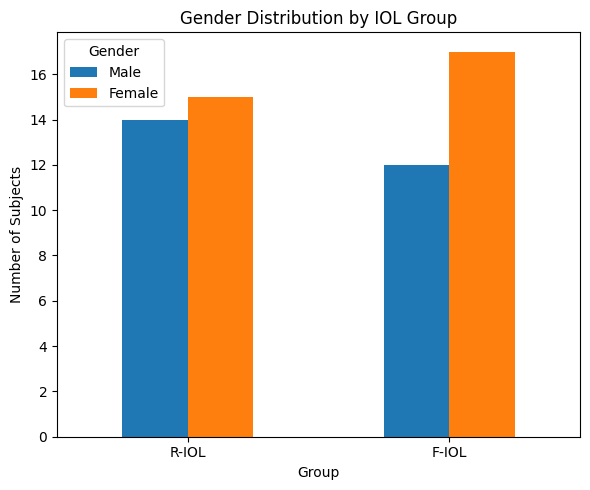

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
gender_df = pd.DataFrame({
    'Group': ['R-IOL', 'F-IOL'],
    'Male': [14, 12],
    'Female': [15, 17]
})

# Plot
ax = gender_df.set_index('Group').plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Gender Distribution by IOL Group')
plt.xlabel('Group')
plt.ylabel('Number of Subjects')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

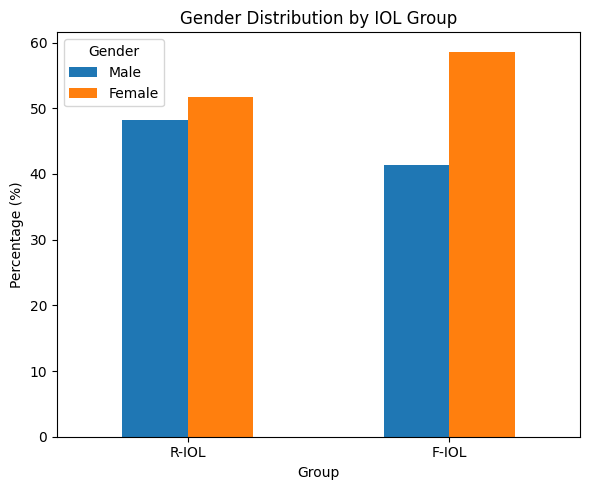

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

gender_pct = pd.DataFrame({
    'Group': ['R-IOL', 'F-IOL'],
    'Male': [48.28, 41.38],
    'Female': [51.72, 58.62]
})

ax = gender_pct.set_index('Group').plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Gender Distribution by IOL Group')
plt.xlabel('Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

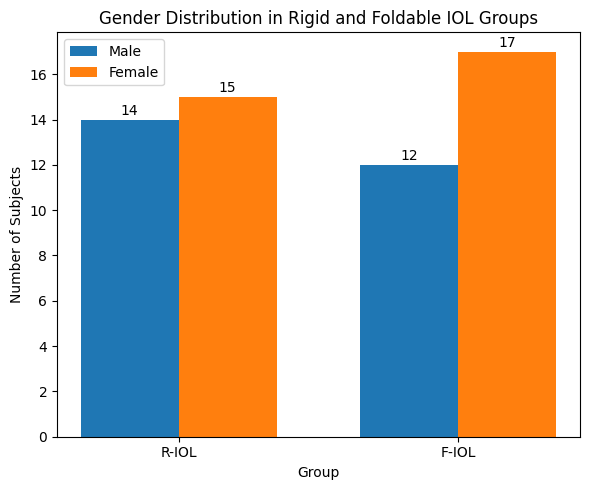

In [21]:
import numpy as np
import matplotlib.pyplot as plt

groups = ['R-IOL', 'F-IOL']
male = [14, 12]
female = [15, 17]

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, male, width, label='Male')
plt.bar(x + width/2, female, width, label='Female')

plt.xlabel('Group')
plt.ylabel('Number of Subjects')
plt.title('Gender Distribution in Rigid and Foldable IOL Groups')
plt.xticks(x, groups)
plt.legend()

# Add value labels
for i, v in enumerate(male):
    plt.text(x[i] - width/2, v + 0.2, str(v), ha='center')

for i, v in enumerate(female):
    plt.text(x[i] + width/2, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()

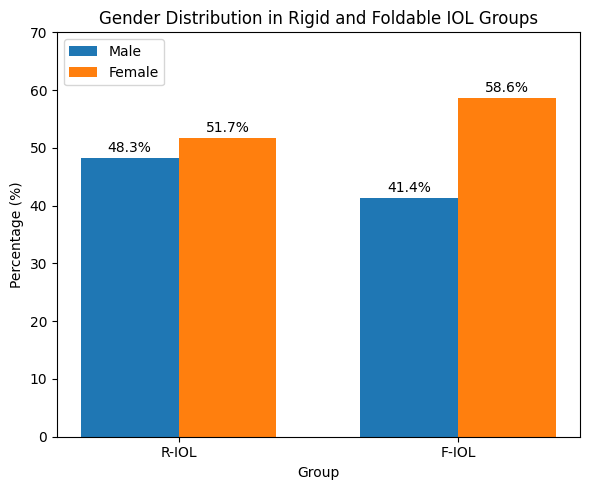

In [22]:
import numpy as np
import matplotlib.pyplot as plt

groups = ['R-IOL', 'F-IOL']
male = [48.28, 41.38]
female = [51.72, 58.62]

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, male, width, label='Male')
plt.bar(x + width/2, female, width, label='Female')

plt.xlabel('Group')
plt.ylabel('Percentage (%)')
plt.title('Gender Distribution in Rigid and Foldable IOL Groups')
plt.xticks(x, groups)
plt.legend()

for i, v in enumerate(male):
    plt.text(x[i] - width/2, v + 1, f'{v:.1f}%',

             ha='center')

for i, v in enumerate(female):
    plt.text(x[i] + width/2, v + 1, f'{v:.1f}%',

             ha='center')

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

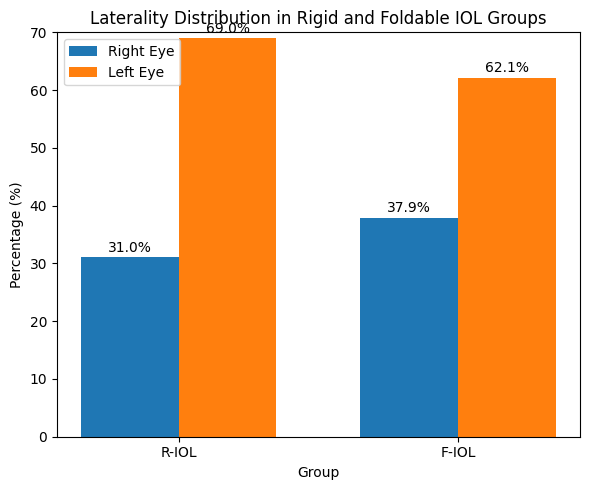

In [23]:
import numpy as np
import matplotlib.pyplot as plt

groups = ['R-IOL', 'F-IOL']

right_eye = [31.03, 37.93]   # Replace with your percentages
left_eye = [68.97, 62.07]    # Replace with your percentages

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, right_eye, width, label='Right Eye')
plt.bar(x + width/2, left_eye, width, label='Left Eye')

plt.xlabel('Group')
plt.ylabel('Percentage (%)')
plt.title('Laterality Distribution in Rigid and Foldable IOL Groups')
plt.xticks(x, groups)
plt.legend()

for i, v in enumerate(right_eye):
    plt.text(x[i] - width/2, v + 1, f'{v:.1f}%', ha='center')

for i, v in enumerate(left_eye):
    plt.text(x[i] + width/2, v + 1, f'{v:.1f}%', ha='center')

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

### Rigid IOL Group Analysis
R preop

R pod1

R pod6wks

R pod3mths

In [24]:
rigid_preop.columns, rigid_pod1.columns, rigid_pod6wks.columns, rigid_pod3mths.columns

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'Preop IOP-R', 'Preop ACD-R ',
        'Preop LV-R', 'Preop CCT-R ', 'Preop ACA-R  ', 'Preop ATA-R ',
        'Preop AOD N 500-R ', 'preop AOD N 750-R ', 'Preop TISA N 500-R ',
        'Preop TISA N 750-R ', 'Preop SSA-N R ', 'Preop AOD T 500-R  ',
        'Preop AOD T 750-R ', 'Preop TISAT  500-R  ', 'Preop TISA T 750-R ',
        'Preop SSA-T-R'],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
        'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
        'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
        'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
        'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-

In [25]:
rigid_preop.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
Preop VA snellen-R,0
Preop LogMAR-R,0
Preop IOP-R,0
Preop ACD-R,0
Preop LV-R,0


In [26]:
rigid_pod1.isnull().sum()
rigid_pod1.dropna(inplace=True)
rigid_pod1.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
Preop VA snellen-R,0
POD1 IOP-R,0
POD1 ACD-R,0
POD1 LV-R,0
POD1 CCT-R,0


In [27]:
rigid_pod6wks.isnull().sum()
rigid_pod6wks.dropna(inplace=True)
rigid_pod6wks.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
POD6wk IOP-R,0
ACD 6 wk-R,0
LV 6 wk-R,0
CCT 6 wk-R,0
ACA POD 6 wk-R,0


In [28]:
rigid_pod3mths.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
POD3 mth IOP -R,17
ACD 3 mth-R,19
LV 3 mth-R,18
CCT 3 mth-R,19
ACA 3 mth-R,19


In [29]:
rigid_pod3mths.dropna(inplace=True)
rigid_pod3mths.isnull().sum()

,0
Name,0
Age-R,0
Sex-R,0
Laterality-R,0
Cataract grading-R,0
POD3 mth IOP -R,0
ACD 3 mth-R,0
LV 3 mth-R,0
CCT 3 mth-R,0
ACA 3 mth-R,0


In [30]:
fold_preop.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
Preop VA (F),0
preop IOP (F),0
Preop ACD (F),0
Preop LV (F),0
Preop CCT (F),0


In [31]:
fold_pod1.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD1 IOP (F),0
ACD POD1 (F),0
LV POD1 (F),0
CCT POD1 (F),0
ACA POD1 (F),0


In [32]:
fold_pod6wks.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD6wk IOP (F),0
ACD 6wk (F),0
LV 6 wk (F),0
CCT 6 wk (F),0
ACA POD 6 wk (F),0


In [33]:
fold_pod3mths.isnull().sum()

,0
Name,0
Age (F),0
Sex (F),0
Cataract grading-F,0
Laterality (F),0
POD 3 mth IOP (F),0
ACD 3 mth (F),0
LV 3 mth (F),0
CCT 3 mth (F),0
ACA 3 mth (F),0


### Rigid IOL within group analysis

In [34]:
rigid_preop.columns,rigid_pod1.columns,rigid_pod6wks.columns,rigid_pod3mths.columns

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'Preop IOP-R', 'Preop ACD-R ',
        'Preop LV-R', 'Preop CCT-R ', 'Preop ACA-R  ', 'Preop ATA-R ',
        'Preop AOD N 500-R ', 'preop AOD N 750-R ', 'Preop TISA N 500-R ',
        'Preop TISA N 750-R ', 'Preop SSA-N R ', 'Preop AOD T 500-R  ',
        'Preop AOD T 750-R ', 'Preop TISAT  500-R  ', 'Preop TISA T 750-R ',
        'Preop SSA-T-R'],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
        'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
        'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
        'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
        'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
       dtype='object'),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-

In [35]:
rigid_pod1.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
       'Preop VA snellen-R ', 'POD1 IOP-R ', 'POD1 ACD-R ', 'POD1 LV-R ',
       'POD1 CCT-R ', 'POD1 ACA-R  ', 'POD1 ATA-R', 'AOD T POD1 500-R',
       'AOD T POD1 750-R ', 'TISA T POD1 500-R ', 'TISA T 750 POD1-R',
       'SSA-T POD1-R ', 'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ',
       'TISA POD1 N 500-R ', 'TISA POD1 N 750-R ', 'SSA-N POD1-R '],
      dtype='object')

### standardising label names uniformly

In [36]:
# Preop
preop_rigid = rigid_preop.rename(columns={
    'Preop IOP-R':'IOP',
    'Preop ACD-R ':'ACD',
    'Preop LV-R':'LV',
    'Preop CCT-R ':'CCT',
    'Preop ACA-R  ':'ACA',
    'Preop ATA-R ':'ATA',
    'Preop AOD N 500-R ':'AOD_N500',
    'preop AOD N 750-R ':'AOD_N750',
    'Preop TISA N 500-R ':'TISA_N500',
    'Preop TISA N 750-R ':'TISA_N750',
    'Preop SSA-N R ':'SSA_N',
    'Preop AOD T 500-R  ':'AOD_T500',
    'Preop AOD T 750-R ':'AOD_T750',
    'Preop TISAT  500-R  ':'TISA_T500',
    'Preop TISA T 750-R ':'TISA_T750',
    'Preop SSA-T-R':'SSA_T'
})

# POD1
pod1_rigid = rigid_pod1.rename(columns={
    'POD1 IOP-R ':'IOP',
    'POD1 ACD-R ':'ACD',
    'POD1 LV-R ':'LV',
    'POD1 CCT-R ':'CCT',
    'POD1 ACA-R  ':'ACA',
    'POD1 ATA-R':'ATA',
    'AOD T POD1 500-R':'AOD_T500',
    'AOD T POD1 750-R ':'AOD_T750',
    'TISA T POD1 500-R ':'TISA_T500',
    'TISA T 750 POD1-R':'TISA_T750',
    'SSA-T POD1-R ':'SSA_T',
    'AOD N POD1 500-R ':'AOD_N500',
    'AOD N POD1 750-R ':'AOD_N750',
    'TISA N POD1 500-R ':'TISA_N500',
    'TISA N POD1 750-R ':'TISA_N750',
    'SSA-N POD1-R ':'SSA_N'


})

# POD6wk
pod6wk_rigid = rigid_pod6wks.rename(columns={
    'POD6wk IOP-R ':'IOP',
    'ACD 6 wk-R ':'ACD',
    'LV 6 wk-R':'LV',
    'CCT 6 wk-R ':'CCT',
    'ACA POD 6 wk-R ':'ACA',
    'ATA 6 wk-R':'ATA',
    'AOD N 500 6 wk-R ':'AOD_N500',
    'AOD N 750 6 wk-R ':'AOD_N750',
    'TISA N 500 6 wk-R ':'TISA_N500',
    'TISA N 750 6 wk-R ':'TISA_N750',
    'SSA-N 6 wk-R ':'SSA_N',
    'AOD T 500 6 wk-R ':'AOD_T500',
    'AOD T 750 6 wk-R ':'AOD_T750',
    'TISA T 500 6 wk-R ':'TISA_T500',
    'TISA T 750 6 wk-R':'TISA_T750',
    'SSA-T 6 wk-R ':'SSA_T'
})

# POD3mth
pod3mth_rigid = rigid_pod3mths.rename(columns={
    'POD3 mth IOP -R':'IOP',
    'ACD 3 mth-R':'ACD',
    'LV 3 mth-R':'LV',
    'CCT 3 mth-R':'CCT',
    'ACA 3 mth-R':'ACA',
    'ATA 3 mth-R':'ATA',
    'AOD 500 N 3 mth-R':'AOD_N500',
    'AOD 750 N 3 mth-R':'AOD_N750',
    'TISA 500 N 3 mth-R':'TISA_N500',
    'TISA 750 N 3 mth-R':'TISA_N750',
    'SSA N 3 mth-R':'SSA_N',
    'AOD 500 T 3 mth-R':'AOD_T500',
    'AOD 750 T 3 mth-R':'AOD_T750',
    'TISA 500 T 3 mth-R':'TISA_T500',
    'TISA 750 T 3 mth-R':'TISA_T750',
    'SSA T 3 mth-R':'SSA_T'
})

In [37]:
pod1_rigid.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
       'Preop VA snellen-R ', 'IOP', 'ACD', 'LV', 'CCT', 'ACA', 'ATA',
       'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750', 'SSA_T',
       'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ', 'TISA POD1 N 500-R ',
       'TISA POD1 N 750-R ', 'SSA_N'],
      dtype='object')

In [38]:
pod6wk_rigid.columns

Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ', 'IOP',
       'ACD', 'LV', 'CCT', 'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500',
       'TISA_N750', 'SSA_N', 'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750',
       'SSA_T'],
      dtype='object')

In [39]:
preop_rigid.columns, preop_rigid.shape

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'Preop LogMAR-R ', 'IOP', 'ACD', 'LV', 'CCT',
        'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500', 'TISA_N750', 'SSA_N',
        'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750', 'SSA_T'],
       dtype='object'),
 (29, 23))

In [40]:
preop_rigid_df = preop_rigid[[
     'ACD', 'ACA',
     'AOD_T500','AOD_N500',
     'AOD_T750', 'AOD_N750',
     'TISA_T500','TISA_N500',
     'TISA_T750', 'TISA_N750',
     'SSA_T', 'SSA_N',
      'ATA', 'LV', 'CCT','IOP'

]]

In [41]:
preop_rigid_df['preop_meanAOD500'] = (preop_rigid['AOD_T500'] + preop_rigid['AOD_N500'])/2

preop_rigid_df['preop_meanAOD750'] = (preop_rigid['AOD_T750'] + preop_rigid['AOD_N750'])/2

preop_rigid_df['preop_meanTISA500'] = (preop_rigid['TISA_T500'] + preop_rigid['TISA_N500'])/2

preop_rigid_df['preop_meanTISA750'] = (preop_rigid['TISA_T750'] + preop_rigid['TISA_N750'])/2

preop_rigid_df['preop_meanSSA'] = (preop_rigid['SSA_T'] + preop_rigid['SSA_N'])/2


/tmp/ipykernel_2066/2099830031.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_rigid_df['preop_meanAOD500'] = (preop_rigid['AOD_T500'] + preop_rigid['AOD_N500'])/2
/tmp/ipykernel_2066/2099830031.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_rigid_df['preop_meanAOD750'] = (preop_rigid['AOD_T750'] + preop_rigid['AOD_N750'])/2
/tmp/ipykernel_2066/2099830031.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [42]:
preop_rigid_df.shape, preop_rigid_df.columns

((29, 21),
 Index(['ACD', 'ACA', 'AOD_T500', 'AOD_N500', 'AOD_T750', 'AOD_N750',
        'TISA_T500', 'TISA_N500', 'TISA_T750', 'TISA_N750', 'SSA_T', 'SSA_N',
        'ATA', 'LV', 'CCT', 'IOP', 'preop_meanAOD500', 'preop_meanAOD750',
        'preop_meanTISA500', 'preop_meanTISA750', 'preop_meanSSA'],
       dtype='object'))

### Preop rigid df baseline analysis AS OCT parameters

In [45]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD',
    'ACA',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA'
]

results = []

for var in variables:

    data = preop_rigid_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD,2.73 ± 0.30,2.70 (2.53–2.94),2.08,3.42,0.982,0.886
1,ACA,21.85 ± 3.83,20.56 (19.56–24.19),14.92,30.92,0.955,0.239
2,preop_meanAOD500,0.44 ± 0.07,0.43 (0.38–0.48),0.30,0.59,0.989,0.985
3,preop_meanAOD750,0.67 ± 0.14,0.67 (0.61–0.73),0.42,1.02,0.926,0.044
4,preop_meanTISA500,0.16 ± 0.02,0.15 (0.15–0.17),0.12,0.20,0.970,0.567
5,preop_meanTISA750,0.30 ± 0.05,0.29 (0.27–0.33),0.21,0.41,0.986,0.953
6,preop_meanSSA,40.64 ± 4.83,41.00 (37.00–44.00),30.50,50.00,0.977,0.746


In [48]:
preop_rigid_df.columns

Index(['ACD', 'ACA', 'AOD_T500', 'AOD_N500', 'AOD_T750', 'AOD_N750',
       'TISA_T500', 'TISA_N500', 'TISA_T750', 'TISA_N750', 'SSA_T', 'SSA_N',
       'ATA', 'LV', 'CCT', 'IOP', 'preop_meanAOD500', 'preop_meanAOD750',
       'preop_meanTISA500', 'preop_meanTISA750', 'preop_meanSSA'],
      dtype='object')

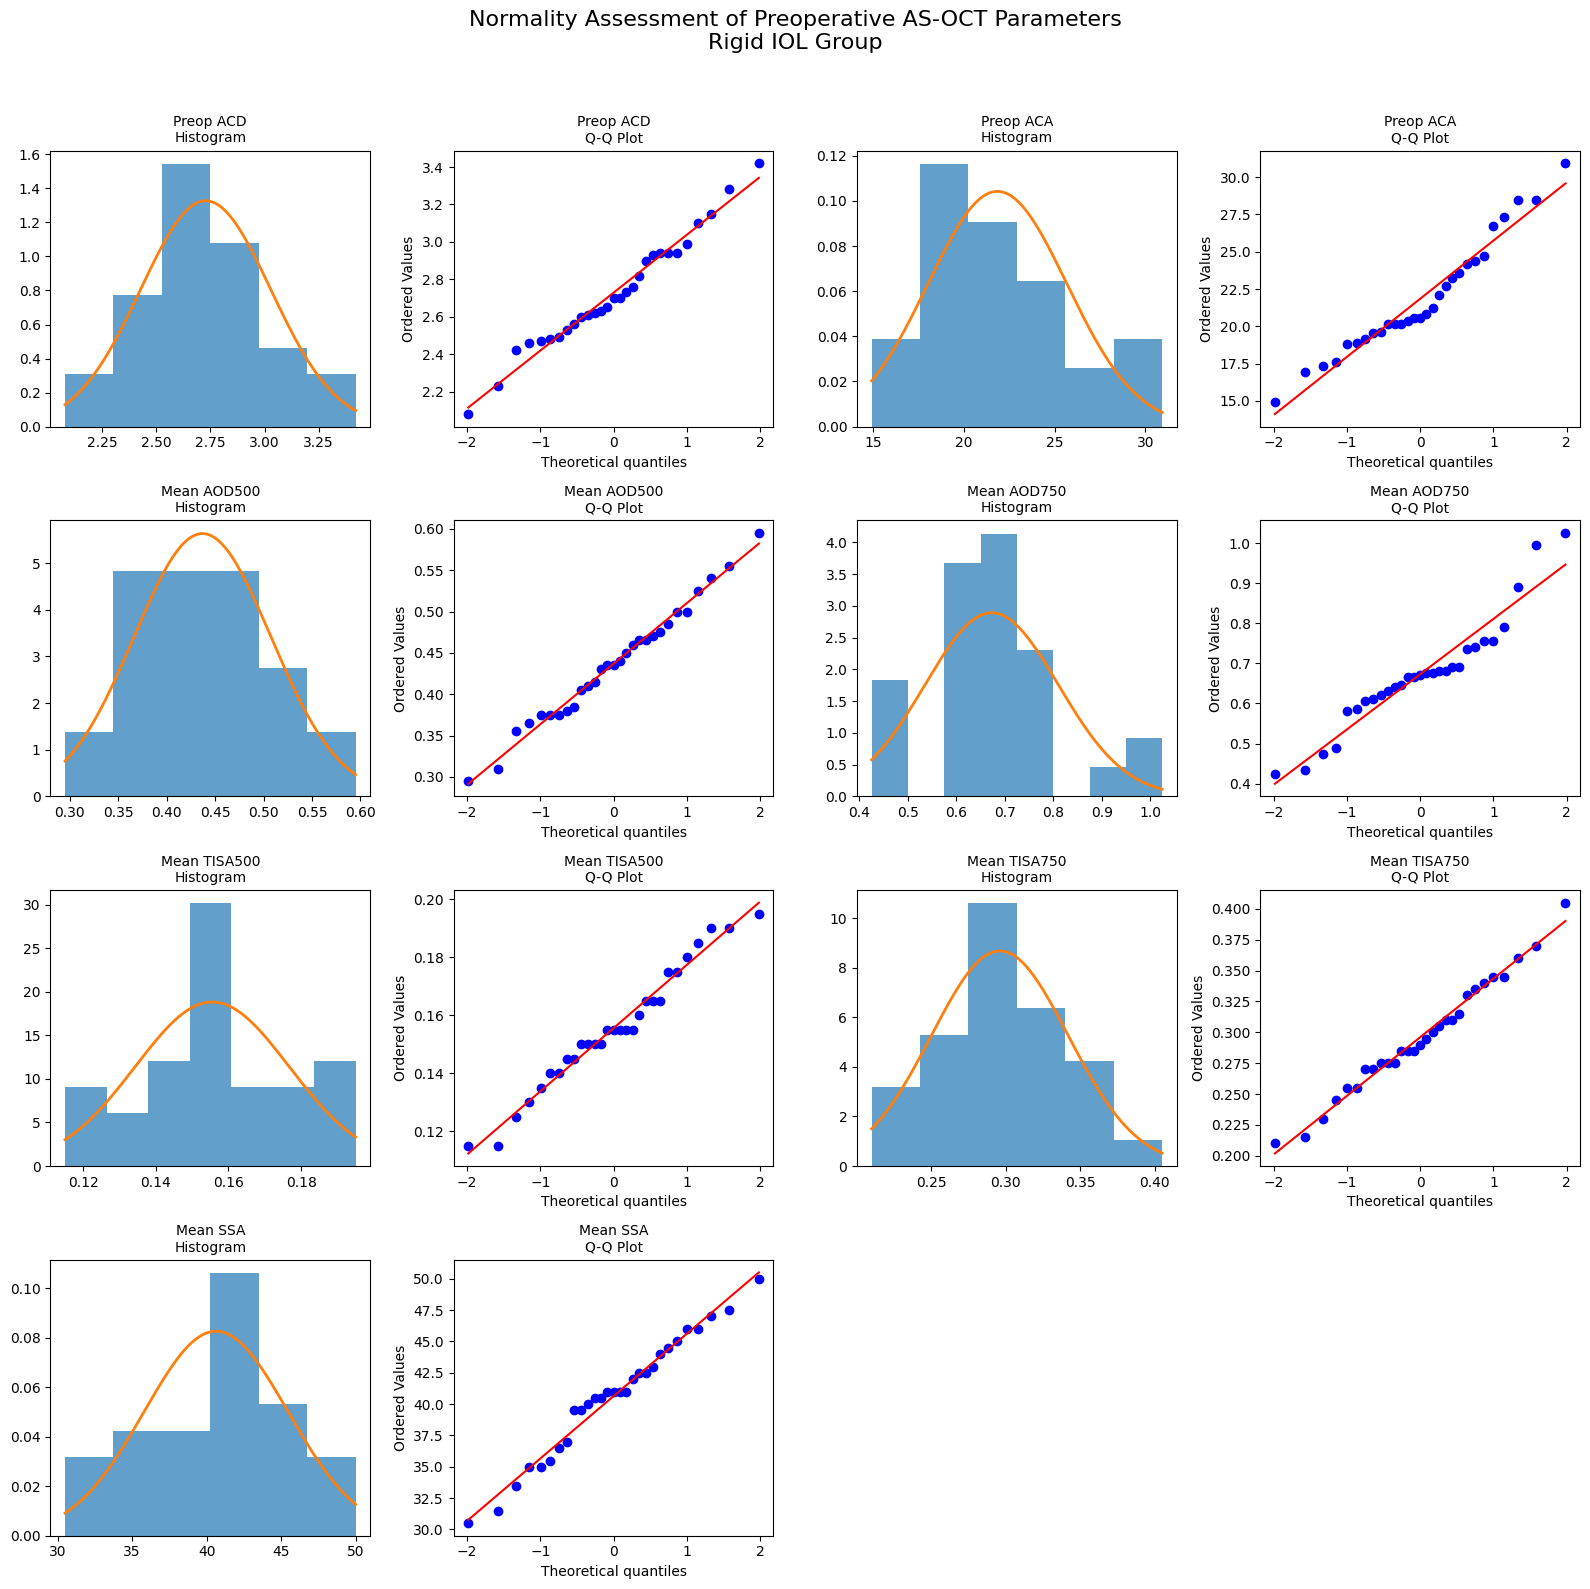

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD',
    'ACA',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA'

]

titles = [
    'Preop ACD',
    'Preop ACA',
    'Mean AOD500',
    'Mean AOD750',
    'Mean TISA500',
    'Mean TISA750',
    'Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = preop_rigid_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of Preoperative AS-OCT Parameters\nRigid IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'Rigid_Preop_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [50]:
from scipy.stats import spearmanr
import pandas as pd

variables = [
    'ACD',
    'ACA',
    'preop_meanAOD500',
    'preop_meanAOD750',
    'preop_meanTISA500',
    'preop_meanTISA750',
    'preop_meanSSA'
]

results = []

for var in variables:

    rho, p = spearmanr(
        preop_rigid_df[var],
        preop_rigid_df['IOP'],
        nan_policy='omit'
    )

    results.append([
        var,
        round(rho, 3),
        round(p, 4)
    ])

spearman_df = pd.DataFrame(
    results,
    columns=['Variable', 'Spearman rho', 'p-value']
)

spearman_df

,Variable,Spearman rho,p-value
0,ACD,-0.140,0.4702
1,ACA,-0.003,0.9858
2,preop_meanAOD500,-0.039,0.8425
3,preop_meanAOD750,-0.122,0.5273
4,preop_meanTISA500,-0.008,0.9690
5,preop_meanTISA750,-0.054,0.7826
6,preop_meanSSA,-0.182,0.3449


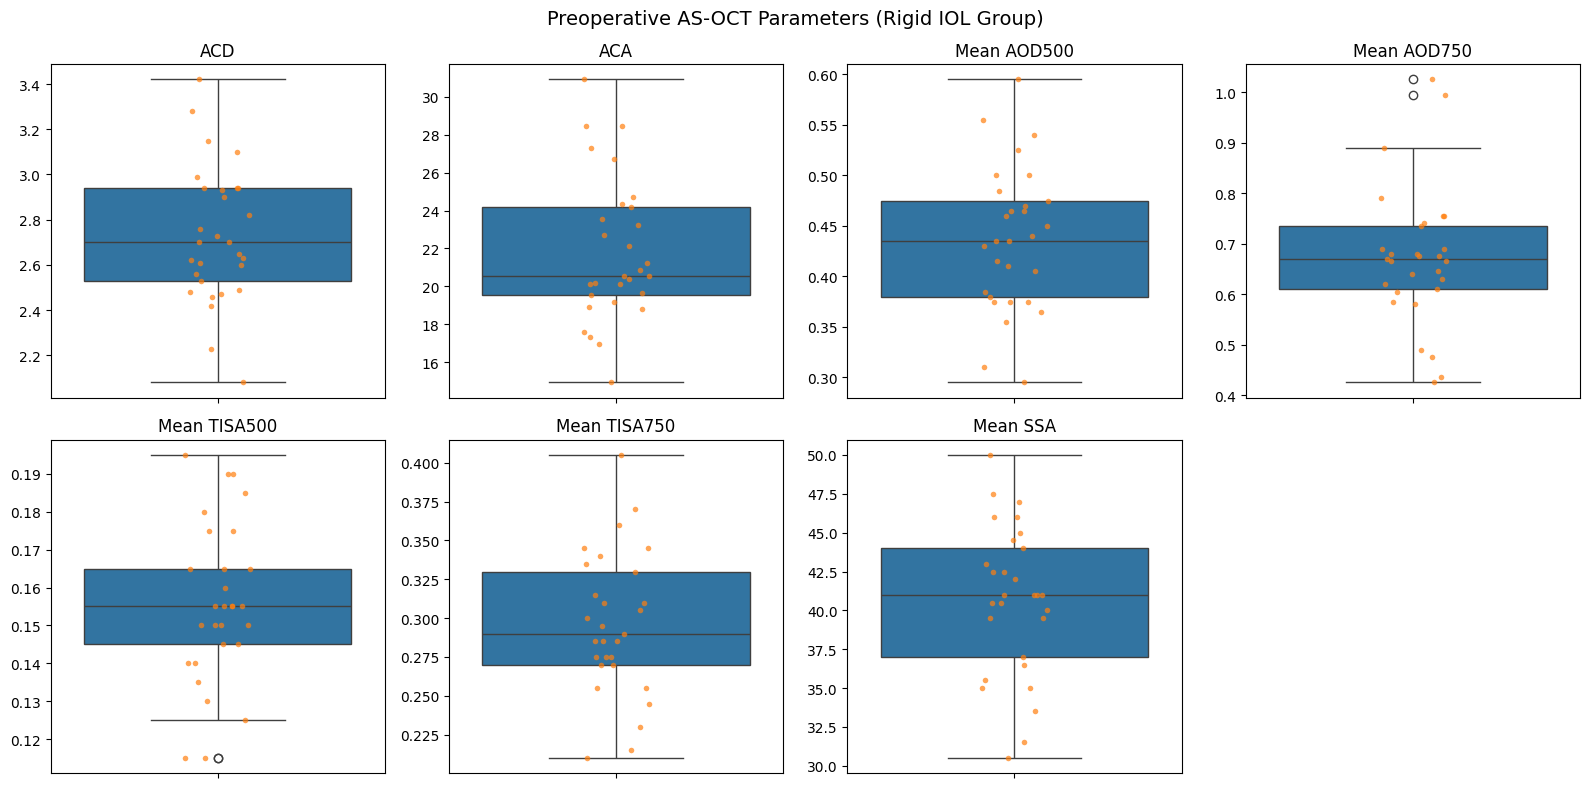

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=preop_rigid_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=preop_rigid_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'Preoperative AS-OCT Parameters (Rigid IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Rigid pod1 analysis



In [54]:
pod1_rigid.shape, pod1_rigid.columns

((25, 22),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ',
        'Preop VA snellen-R ', 'IOP', 'ACD', 'LV', 'CCT', 'ACA', 'ATA',
        'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750', 'SSA_T',
        'AOD POD1 N 500-R ', 'AOD POD1 N 750-R  ', 'TISA POD1 N 500-R ',
        'TISA POD1 N 750-R ', 'SSA_N'],
       dtype='object'))

In [55]:
pod1_rigid_df = pod1_rigid[[
    'ACD', 'ACA',
    'AOD_T500', 'AOD POD1 N 500-R ',
    'AOD_T750', 'AOD POD1 N 750-R  ',
    'TISA_T500', 'TISA POD1 N 500-R ',
    'TISA_T750', 'TISA POD1 N 750-R ',
    'SSA_T','SSA_N',
    'ATA', 'LV', 'CCT', 'IOP'
]]

In [56]:
pod1_rigid_df['pod1_meanAOD500'] = (pod1_rigid['AOD_T500'] + pod1_rigid['AOD POD1 N 500-R '])/2

pod1_rigid_df['pod1_meanAOD750'] = (pod1_rigid['AOD_T750'] + pod1_rigid['AOD POD1 N 750-R  '])/2

pod1_rigid_df['pod1_meanTISA500'] = (pod1_rigid['TISA_T500'] + pod1_rigid['TISA POD1 N 500-R '])/2

pod1_rigid_df['pod1_meanTISA750'] = (pod1_rigid['TISA_T750'] + pod1_rigid['TISA POD1 N 750-R '])/2

pod1_rigid_df['pod1_meanSSA'] = (pod1_rigid['SSA_T'] + pod1_rigid['SSA_N'])/2

/tmp/ipykernel_2066/588638811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod1_rigid_df['pod1_meanAOD500'] = (pod1_rigid['AOD_T500'] + pod1_rigid['AOD POD1 N 500-R '])/2
/tmp/ipykernel_2066/588638811.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pod1_rigid_df['pod1_meanAOD750'] = (pod1_rigid['AOD_T750'] + pod1_rigid['AOD POD1 N 750-R  '])/2
/tmp/ipykernel_2066/588638811.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [57]:
pod1_rigid_df.columns

Index(['ACD', 'ACA', 'AOD_T500', 'AOD POD1 N 500-R ', 'AOD_T750',
       'AOD POD1 N 750-R  ', 'TISA_T500', 'TISA POD1 N 500-R ', 'TISA_T750',
       'TISA POD1 N 750-R ', 'SSA_T', 'SSA_N', 'ATA', 'LV', 'CCT', 'IOP',
       'pod1_meanAOD500', 'pod1_meanAOD750', 'pod1_meanTISA500',
       'pod1_meanTISA750', 'pod1_meanSSA'],
      dtype='object')

In [58]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD',
    'ACA',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'
]

results = []

for var in variables:

    data = pod1_rigid_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD,3.97 ± 0.28,3.96 (3.80–4.23),3.30,4.42,0.961,0.432
1,ACA,27.43 ± 2.46,27.54 (26.27–29.49),22.87,32.56,0.968,0.605
2,pod1_meanAOD500,0.59 ± 0.08,0.57 (0.55–0.65),0.43,0.74,0.962,0.466
3,pod1_meanAOD750,0.86 ± 0.09,0.85 (0.81–0.92),0.68,1.01,0.960,0.421
4,pod1_meanTISA500,0.19 ± 0.02,0.19 (0.18–0.20),0.16,0.23,0.945,0.193
5,pod1_meanTISA750,0.38 ± 0.04,0.36 (0.35–0.40),0.30,0.48,0.977,0.814
6,pod1_meanSSA,48.82 ± 3.26,48.50 (47.00–51.00),40.00,55.00,0.974,0.757


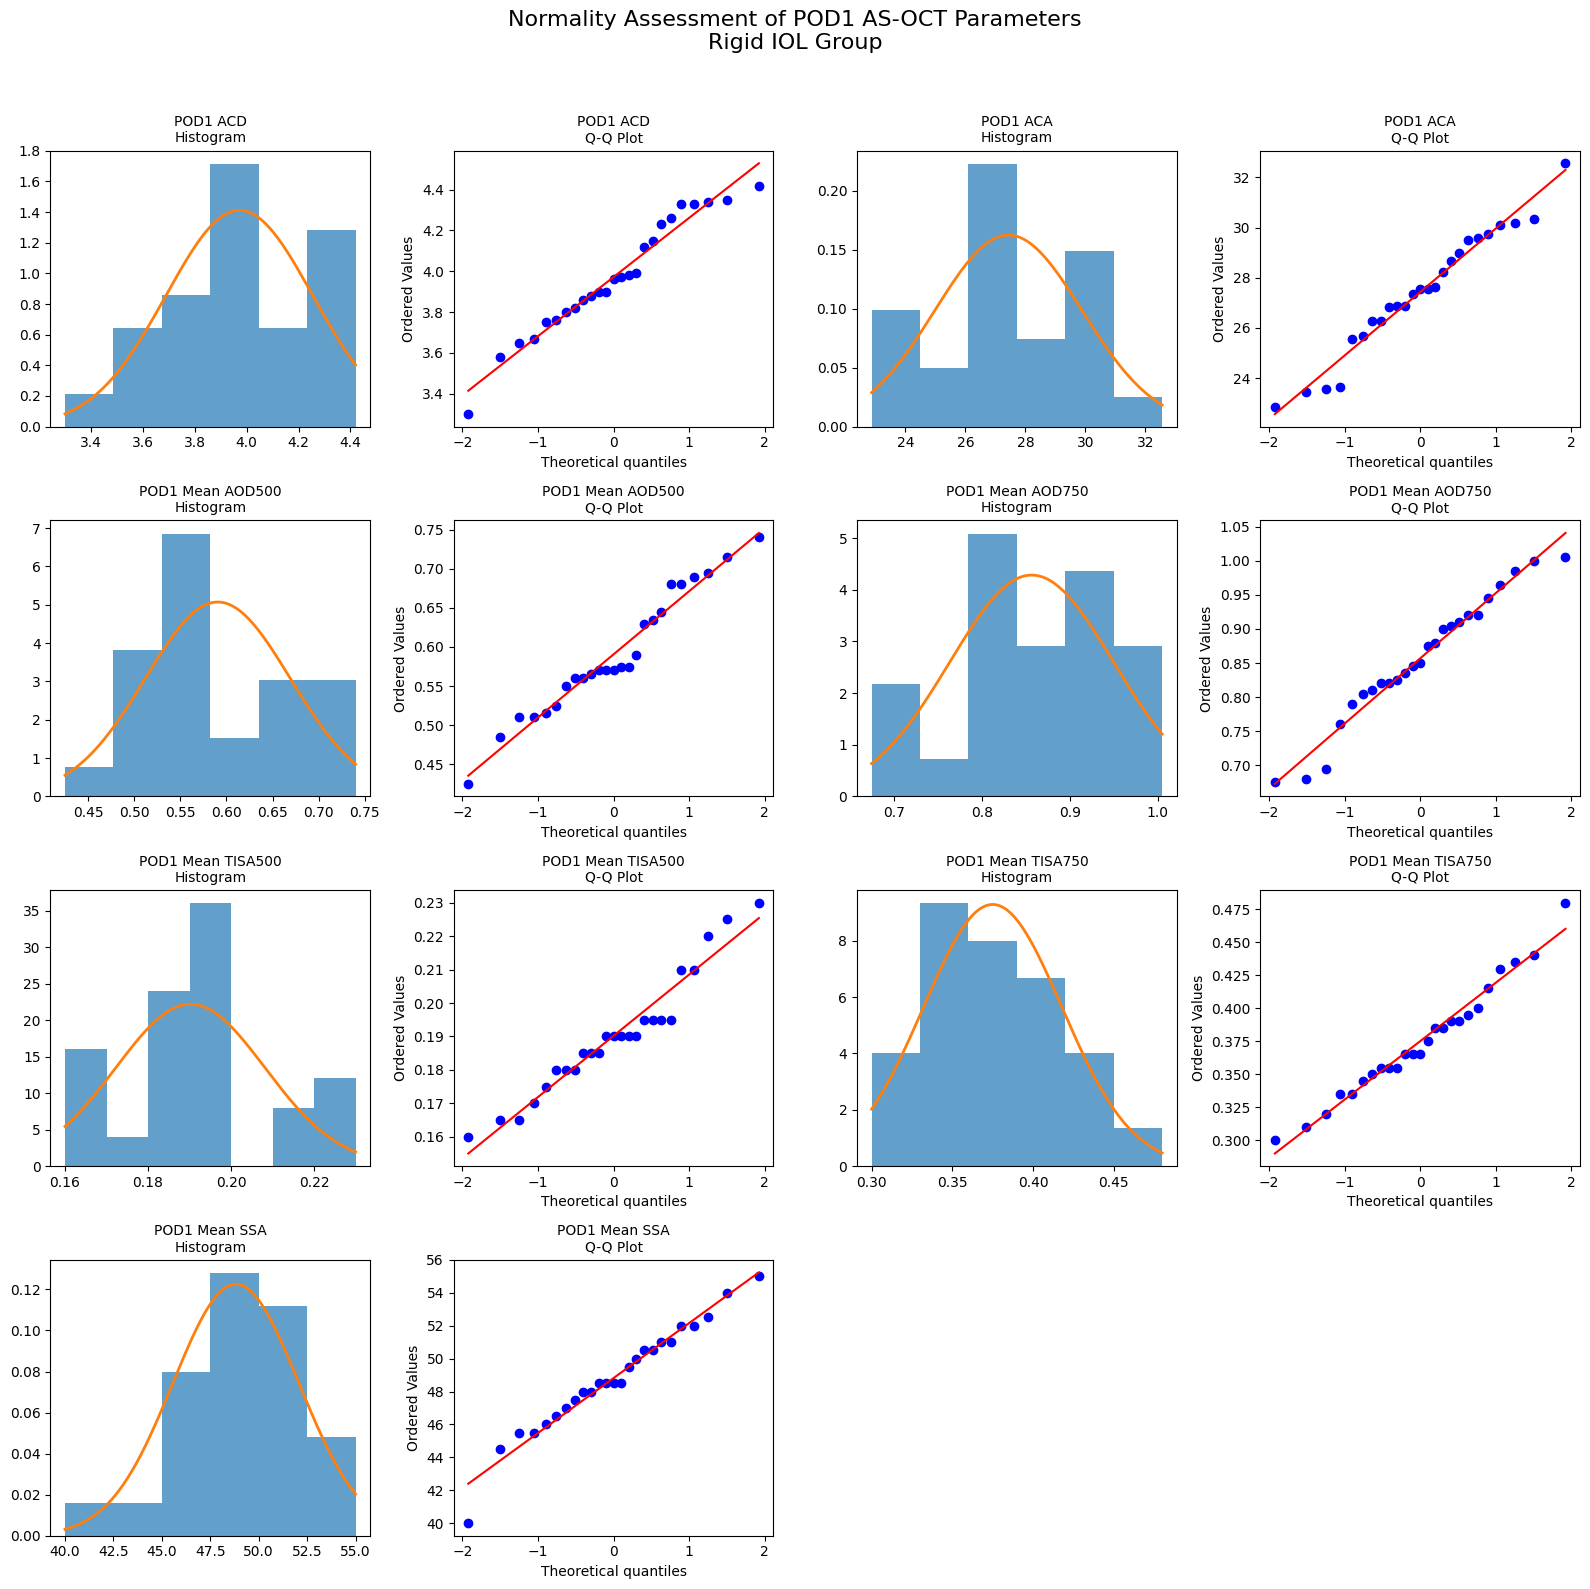

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD',
    'ACA',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'

]

titles = [
    'POD1 ACD',
    'POD1 ACA',
    'POD1 Mean AOD500',
    'POD1 Mean AOD750',
    'POD1 Mean TISA500',
    'POD1 Mean TISA750',
    'POD1 Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod1_rigid_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of POD1 AS-OCT Parameters\nRigid IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'Rigid_POD1_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [60]:
from scipy.stats import spearmanr
import pandas as pd

variables = [
    'ACD',
    'ACA',
    'pod1_meanAOD500',
    'pod1_meanAOD750',
    'pod1_meanTISA500',
    'pod1_meanTISA750',
    'pod1_meanSSA'
]

results = []

for var in variables:

    rho, p = spearmanr(
        pod1_rigid_df[var],
        pod1_rigid_df['IOP'],
        nan_policy='omit'
    )

    results.append([
        var,
        round(rho, 3),
        round(p, 4)
    ])

spearman_df = pd.DataFrame(
    results,
    columns=['Variable', 'Spearman rho', 'p-value']
)

spearman_df

,Variable,Spearman rho,p-value
0,ACD,-0.020,0.9234
1,ACA,-0.045,0.8310
2,pod1_meanAOD500,0.224,0.2814
3,pod1_meanAOD750,0.167,0.4263
4,pod1_meanTISA500,0.101,0.6324
5,pod1_meanTISA750,0.212,0.3089
6,pod1_meanSSA,0.115,0.5830


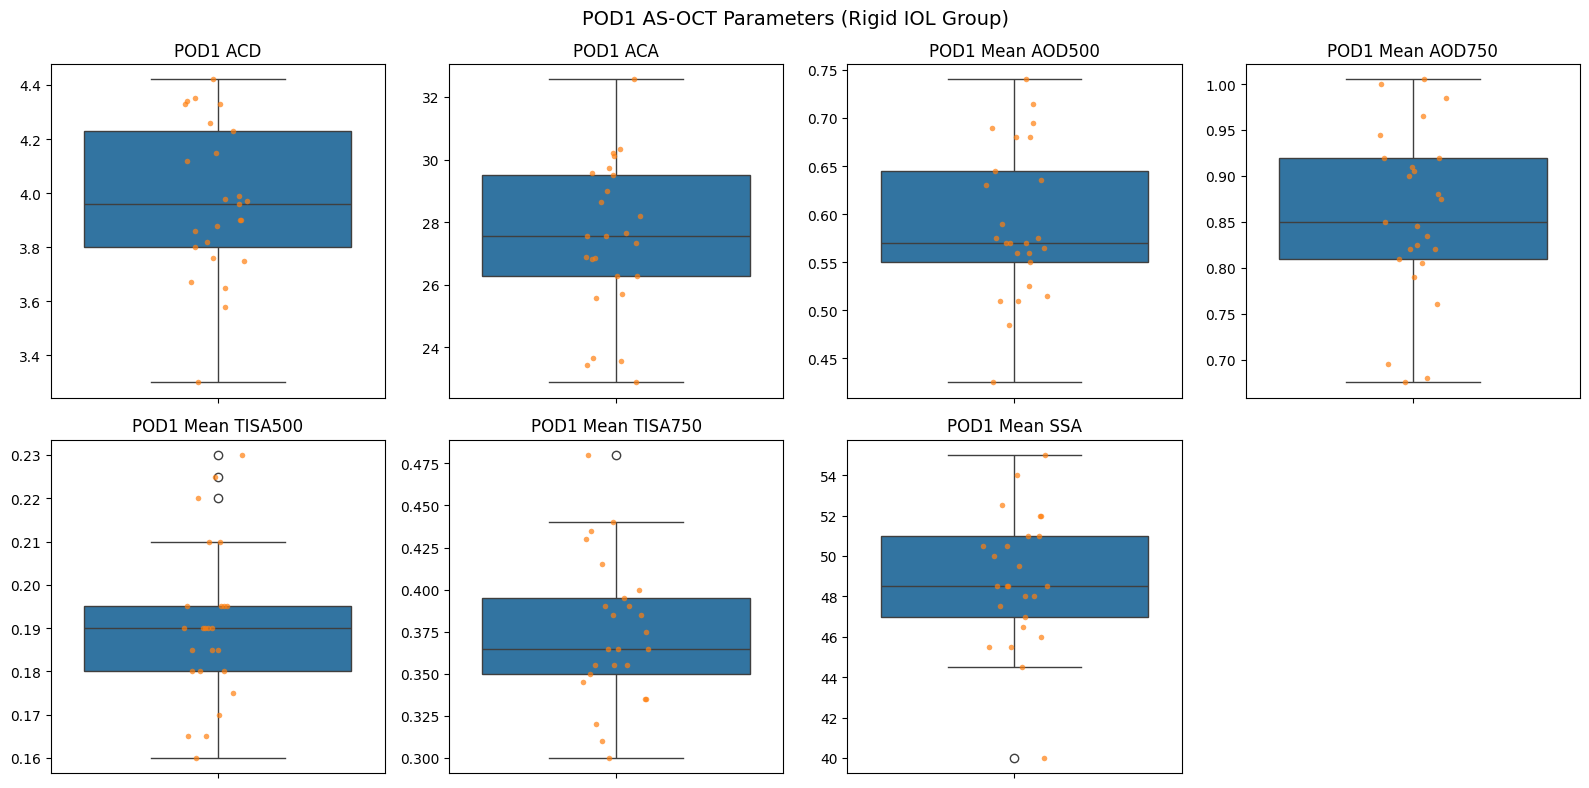

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod1_rigid_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod1_rigid_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'POD1 AS-OCT Parameters (Rigid IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Rigid POD 6 weeks analysis

In [70]:
pod6wk_rigid.columns, pod6wk_rigid.shape

(Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ', 'IOP',
        'ACD', 'LV', 'CCT', 'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500',
        'TISA_N750', 'SSA_N', 'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750',
        'SSA_T'],
       dtype='object'),
 (21, 21))

In [66]:
pod6wk_rigid_df = pod6wk_rigid[[
    'ACD', 'ACA',
    'AOD_T500', 'AOD_N500',
    'AOD_T750', 'AOD_N750',
    'TISA_T500', 'TISA_N500',
    'TISA_T750', 'TISA_N750',
    'SSA_T','SSA_N',
    'ATA', 'LV', 'CCT', 'IOP'
]]

In [69]:
pod6wk_rigid_df['pod6wk_meanAOD500'] = (pod6wk_rigid['AOD_T500'] + pod6wk_rigid['AOD_N500'])/2

pod6wk_rigid_df['pod6wk_meanAOD750'] = (pod6wk_rigid['AOD_T750'] + pod6wk_rigid['AOD_N750'])/2

pod6wk_rigid_df['pod6wk_meanTISA500'] = (pod6wk_rigid['TISA_T500'] + pod6wk_rigid['TISA_N500'])/2

pod6wk_rigid_df['pod6wk_meanTISA750'] = (pod6wk_rigid['TISA_T750'] + pod6wk_rigid['TISA_N750'])/2

pod6wk_rigid_df['pod6wk_meanSSA'] = (pod6wk_rigid['SSA_T'] + pod6wk_rigid['SSA_N'])/2


In [71]:
import pandas as pd
from scipy.stats import shapiro

variables = [
    'ACD',
    'ACA',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA'
]

results = []

for var in variables:

    data = pod6wk_rigid_df[var].dropna()

    W, p = shapiro(data)

    results.append([
        var,
        f"{data.mean():.2f} ± {data.std():.2f}",
        f"{data.median():.2f} ({data.quantile(0.25):.2f}–{data.quantile(0.75):.2f})",
        round(data.min(), 2),
        round(data.max(), 2),
        round(W, 3),
        round(p, 3)
    ])

desc_table = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'Mean ± SD',
        'Median (IQR)',
        'Minimum',
        'Maximum',
        'Shapiro-Wilk W',
        'p-value'
    ]
)

desc_table

,Variable,Mean ± SD,Median (IQR),Minimum,Maximum,Shapiro-Wilk W,p-value
0,ACD,3.74 ± 0.24,3.70 (3.63–3.83),3.23,4.28,0.975,0.836
1,ACA,26.28 ± 2.90,26.13 (24.65–27.67),19.07,34.17,0.928,0.125
2,pod6wk_meanAOD500,0.51 ± 0.06,0.51 (0.48–0.54),0.40,0.63,0.986,0.987
3,pod6wk_meanAOD750,0.74 ± 0.08,0.74 (0.70–0.80),0.55,0.85,0.921,0.089
4,pod6wk_meanTISA500,0.17 ± 0.02,0.17 (0.17–0.18),0.15,0.21,0.927,0.119
5,pod6wk_meanTISA750,0.32 ± 0.03,0.32 (0.29–0.33),0.27,0.39,0.948,0.314
6,pod6wk_meanSSA,45.02 ± 3.69,45.00 (43.00–47.50),38.50,52.00,0.974,0.812


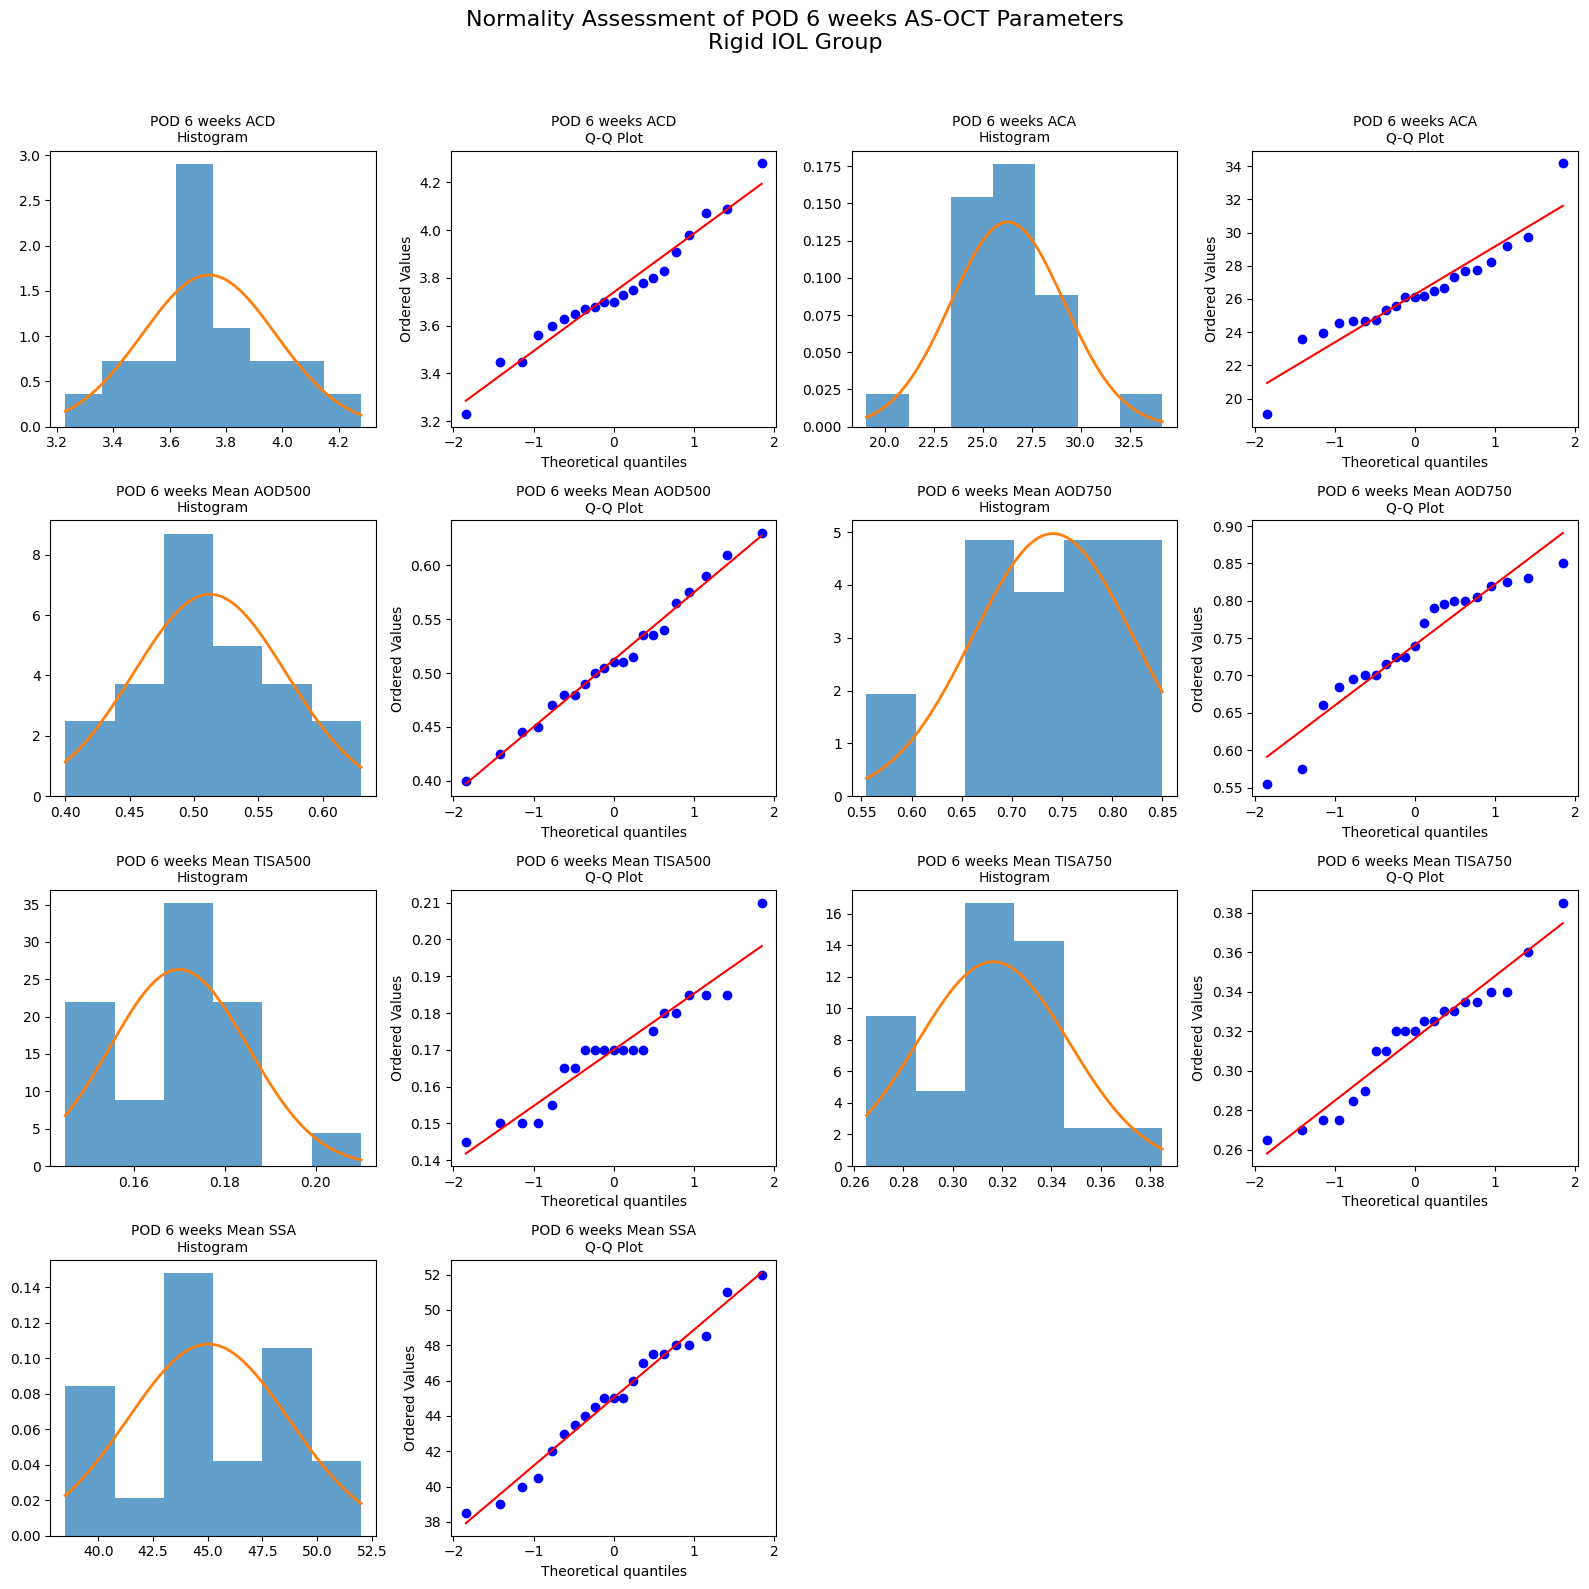

In [72]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, probplot

variables = [
    'ACD',
    'ACA',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA'

]

titles = [
    'POD 6 weeks ACD',
    'POD 6 weeks ACA',
    'POD 6 weeks Mean AOD500',
    'POD 6 weeks Mean AOD750',
    'POD 6 weeks Mean TISA500',
    'POD 6 weeks Mean TISA750',
    'POD 6 weeks Mean SSA',

]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

panel = 0

for var, title in zip(variables, titles):

    data = pod6wk_rigid_df[var].dropna()

    # Histogram + Normal Curve
    axes[panel].hist(data, bins='auto', density=True, alpha=0.7)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)

    axes[panel].plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2
    )

    axes[panel].set_title(f'{title}\nHistogram', fontsize=10)
    panel += 1

    # QQ Plot
    probplot(data, dist='norm', plot=axes[panel])
    axes[panel].set_title(f'{title}\nQ-Q Plot', fontsize=10)
    panel += 1

# Hide unused panels
for i in range(panel, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Normality Assessment of POD 6 weeks AS-OCT Parameters\nRigid IOL Group',
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    'Rigid_POD6wk_Normality_4x4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [73]:
from scipy.stats import spearmanr
import pandas as pd

variables = [
    'ACD',
    'ACA',
    'pod6wk_meanAOD500',
    'pod6wk_meanAOD750',
    'pod6wk_meanTISA500',
    'pod6wk_meanTISA750',
    'pod6wk_meanSSA'
]

results = []

for var in variables:

    rho, p = spearmanr(
        pod6wk_rigid_df[var],
        pod6wk_rigid_df['IOP'],
        nan_policy='omit'
    )

    results.append([
        var,
        round(rho, 3),
        round(p, 4)
    ])

spearman_df = pd.DataFrame(
    results,
    columns=['Variable', 'Spearman rho', 'p-value']
)

spearman_df

,Variable,Spearman rho,p-value
0,ACD,0.239,0.2965
1,ACA,0.206,0.3699
2,pod6wk_meanAOD500,0.105,0.6510
3,pod6wk_meanAOD750,-0.055,0.8131
4,pod6wk_meanTISA500,0.105,0.6511
5,pod6wk_meanTISA750,0.041,0.8601
6,pod6wk_meanSSA,-0.036,0.8779


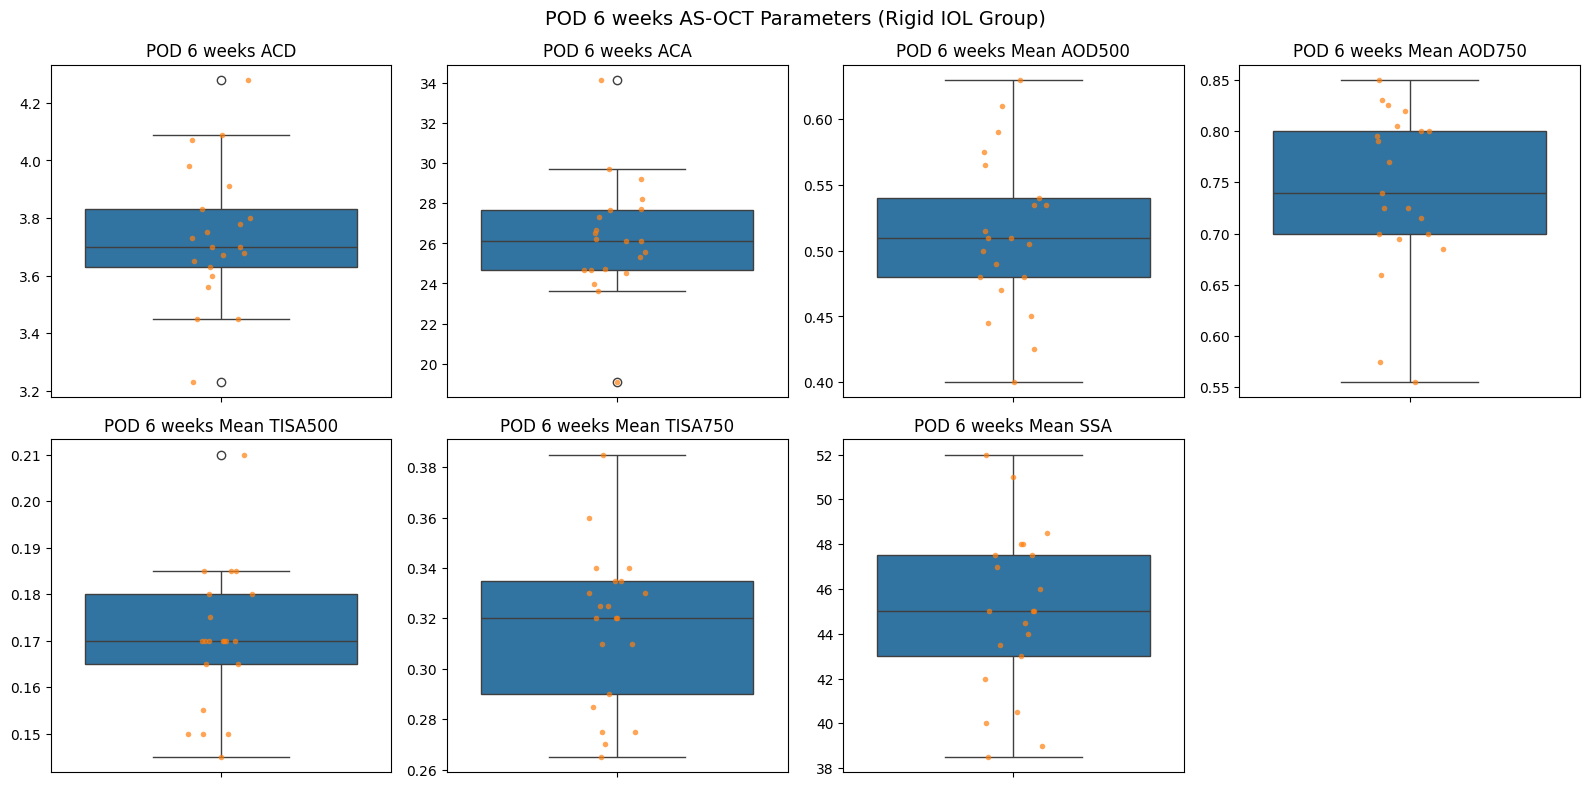

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(variables, titles)):

    sns.boxplot(
        y=pod6wk_rigid_df[var],
        ax=axes[i]
    )

    sns.stripplot(
        y=pod6wk_rigid_df[var],
        ax=axes[i],
        size=4,
        alpha=0.7
    )

    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off')

plt.suptitle(
    'POD 6 weeks AS-OCT Parameters (Rigid IOL Group)',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Rigid 3 months analysis

In [75]:
pod3mth_rigid.shape, pod3mth_rigid.columns

((9, 21),
 Index(['Name', 'Age-R', 'Sex-R', 'Laterality-R', 'Cataract grading-R ', 'IOP',
        'ACD', 'LV', 'CCT', 'ACA', 'ATA', 'AOD_N500', 'AOD_N750', 'TISA_N500',
        'TISA_N750', 'SSA_N', 'AOD_T500', 'AOD_T750', 'TISA_T500', 'TISA_T750',
        'SSA_T'],
       dtype='object'))